## Objective

Use Mixed Media Modeling (MMM) to help the marketing team understand how to most effectively spend their advertising budget with a focus on which ad platforms drives new customer acquisition.

## Questions

* Is there seasonality?
* Is there a day of week effect?
* How have sales treneded over time, regardless of recent marketing spend?
* What is an average sales cycle?
* What other features affect sales that we don't have captured in this dataset?

## Approach

1. Load Data
2. Perform EDA:
    * Plot sales, orders, new customers, and sessions by week
    * Plot month and year adjusted average sales by day of week
    * Correlation analysis on optimal lag of advertisement to new customer conversion
3. Formulate regression model to estimate customer acquisition cost
4. Takeaways

## Limitations

* In the abscence of an A/B Test, causality of the marketing effectiveness remains elusive. 
* Regression analysis has limitations around isolating treatment effects of a given marketing campaign. 
* Lack external data such as inventory/service levels, competitor promotions, etc. 

## Set Up

#### Load Modules

In [21]:
# Standard modules
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta, TH
import datetime


# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Models and evaluation
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler

## Load Data and Prep Data

In [22]:
df = pd.read_csv("inputs/Bertram_BikeSalesData.csv")
df.head(2)

,Date,Orders,Text_Subscribes,Sessions,Net_Sales,New_Customer_Count,Bikes_Sold,Google_Spend,YouTube_Spend,Bing_Spend,Facebook_Spend,TikTok_Spend,Amazon_Spend,Podcast_Spend,SMS Spend
0,2024-08-31,209,242,20171,236715,111,169,10506,4568,1363,5445,312,283,0,542
1,2024-08-30,186,255,19793,169142,125,152,8585,1594,1429,3866,265,288,0,211


In [23]:
# Set parameters of spend columns and target column
spend_cols = [
    'Google_Spend', 'YouTube_Spend', 'Bing_Spend', 'Facebook_Spend',
    'TikTok_Spend', 'Amazon_Spend', 'Podcast_Spend', 'SMS Spend'
]
target_col = ['New_Customer_Count']

In [24]:
# Cast Date as date type
df['Date'] = pd.to_datetime(df['Date'])


# Add time features
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['DayOfWeek'] = df['Date'].dt.day_name() # 0 = Monday

df['year_week'] = df['Date'].dt.to_period('W').apply(lambda r: r.start_time)
df['year_month'] = df['Date'].dt.to_period('M')


In [25]:
# Function to calculate Thanksgiving (4th Thursday of November)
def get_thanksgiving(year):
    return datetime.date(year, 11, 1) + relativedelta(weekday=TH(4))

# Create flag column
def is_between_thanksgiving_and_christmas(date):
    year = date.year
    thanksgiving = get_thanksgiving(year)
    christmas = datetime.date(year, 12, 25)
    return thanksgiving <= date.date() <= christmas

# Between thanksgiving and christmas
df['Between_TG_and_Christmas'] = df['Date'].apply(is_between_thanksgiving_and_christmas)

## EDA

#### Seasonality and Year Effects: New Customer Acquisition

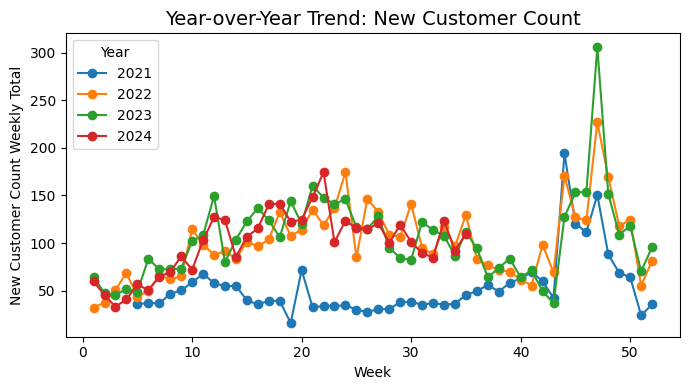

In [26]:
# Pivot to show values by week and year
pivot_df = df.pivot_table(index='Week', columns='Year', values='New_Customer_Count')

# Plot
ax = pivot_df.plot(figsize=(7, 4), marker='o')
ax.set_title(f'Year-over-Year Trend: New Customer Count', fontsize=14)
ax.set_xlabel('Week')
ax.set_ylabel(f'New Customer Count Weekly Total')
ax.legend(title='Year')
plt.tight_layout()
plt.show()

New customer acquisition by week indicates that there is seasonality, with increases in sales before the holiday season and during warmer months.New customer acquisition has remained largely constant since 2021.

#### Day of Week Effects

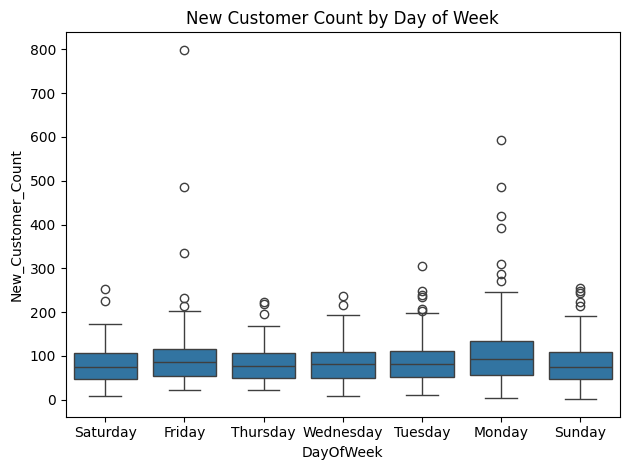

In [27]:
figsize=(7, 4)
sns.boxplot(x='DayOfWeek', y='New_Customer_Count', data=df.reset_index())
plt.title("New Customer Count by Day of Week")
plt.tight_layout()
plt.show()

Mondays tend to have higher new customer counts. 

#### Seasonality and Year Effects: Spending Channels

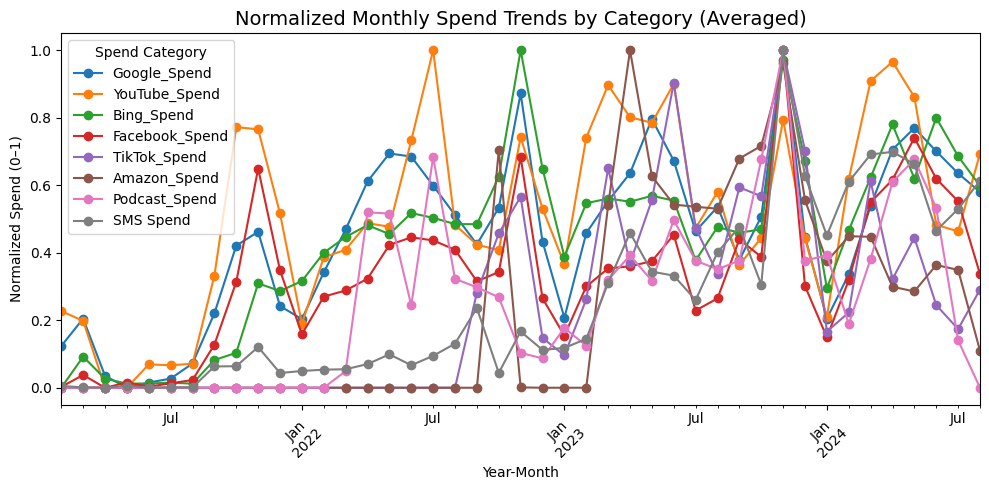

In [28]:
# Group by Year and Month, and take the average
df_monthly = df.groupby(['year_month'])[spend_cols].mean().reset_index()

# Normalize spend columns (0–1 range)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_monthly[spend_cols]),
    columns=spend_cols,
    index=df_monthly['year_month']
)

# Plot
ax = df_scaled.plot(figsize=(10, 5), marker='o')
ax.set_title('Normalized Monthly Spend Trends by Category (Averaged)', fontsize=14)
ax.set_xlabel('Year-Month')
ax.set_ylabel('Normalized Spend (0–1)')
ax.legend(title='Spend Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Not all categories picked up spending until 2023. Spending is relatively constant between channels over time. 

#### Average Spend by Category

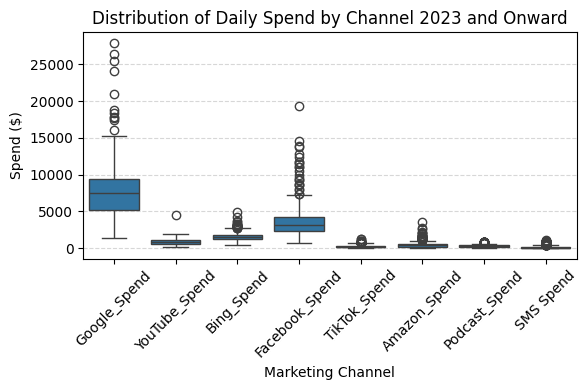

In [29]:
# Melt the spend columns into long format for plotting
df_melted = df[df['Year'] >= 2023][spend_cols].reset_index().melt(id_vars='index', 
                                               value_vars=spend_cols, 
                                               var_name='Channel', 
                                               value_name='Spend')

# Create the boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x='Channel', y='Spend', data=df_melted)
plt.title('Distribution of Daily Spend by Channel 2023 and Onward')
plt.xlabel('Marketing Channel')
plt.ylabel('Spend ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Search Engine spend dominates, particularly google. Though facebook and youtube have sizeable average spend as well.

#### Distributions

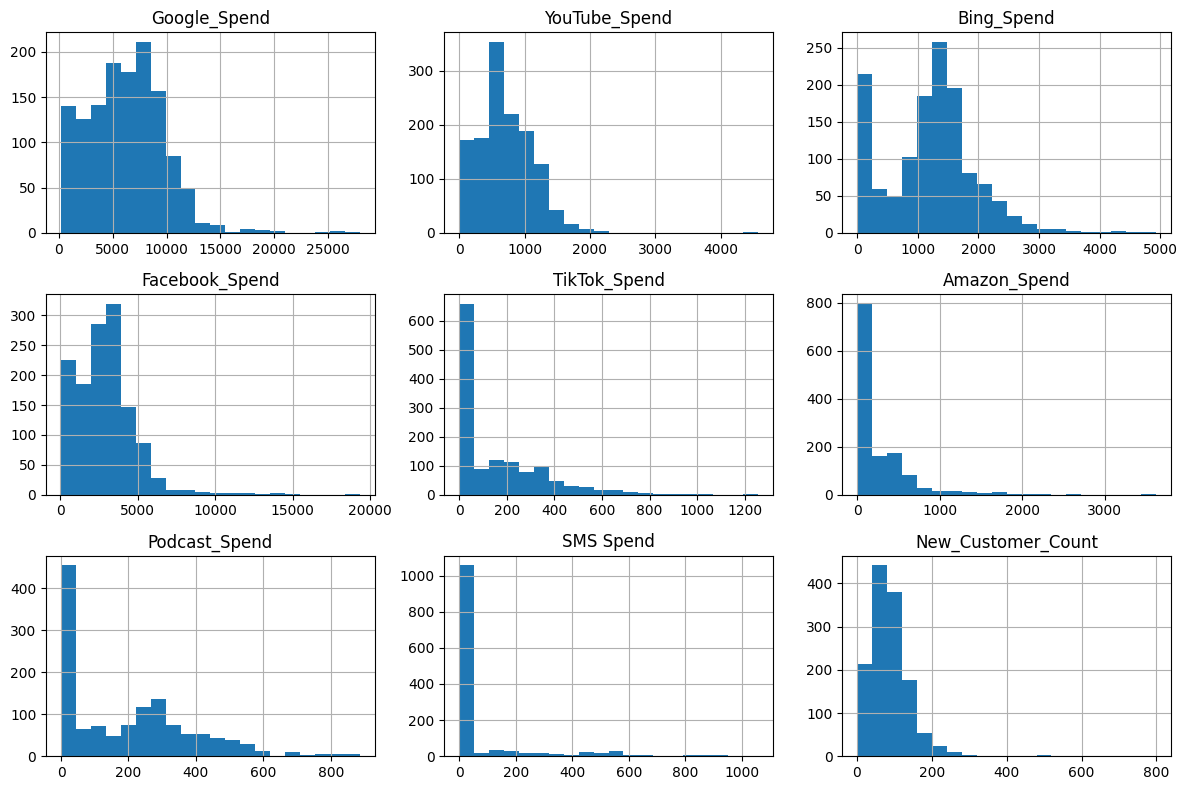

In [30]:
# Histogram of numeric features
numeric_cols = df[spend_cols + target_col].columns
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

All plots indicate the spend and new customer count are right skewed, a log transformation may be necessary if model assumptions are not met.

#### Correlation Analysis

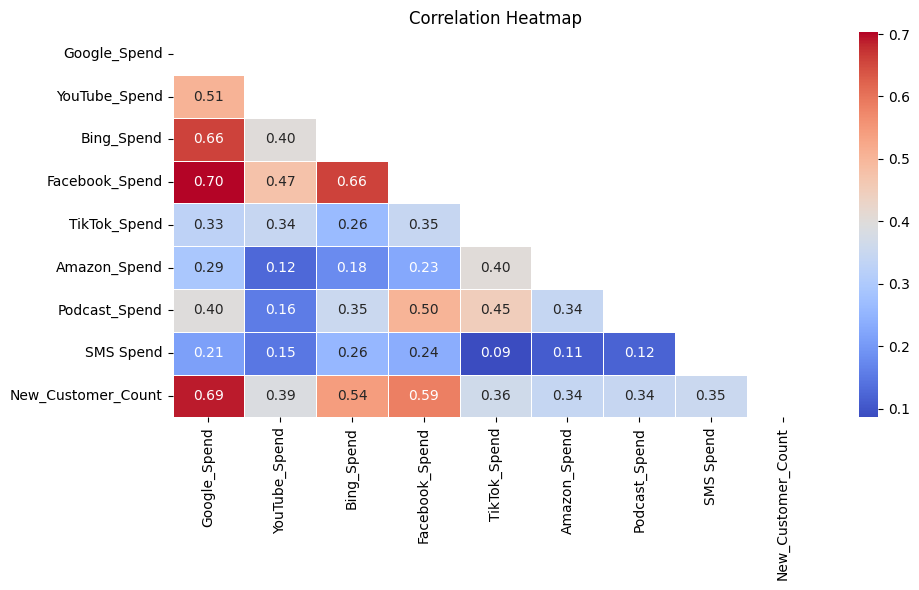

In [31]:
# create correlation data
df_logcorr = df[df['Year'] >= 2023].copy()

target_col = ['New_Customer_Count']
corr_subset = df_logcorr[spend_cols + target_col]

# Compute the correlation matrix
corr = corr_subset.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot the half-heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

A basic correlation analysis indicates that google and facebook ad spending is most correlated with new customer growth.

#### Lag/Rolling mean Tests

In [32]:
# Candidate rolling window sizes
windows = [1, 2, 3, 5, 7, 10, 14]
results = []

for window in windows:
    df_rolled = df[df['Year'] >= 2023].copy()

    # Calculate total spend and apply rolling mean
    df_rolled['Total_Spend'] = df_rolled[spend_cols].sum(axis=1)
    df_rolled['Total_Spend_Roll'] = df_rolled['Total_Spend'].rolling(window=window).mean()

    # Drop rows with NA (from rolling)
    df_rolled = df_rolled.dropna()

    # Feature and target
    X = sm.add_constant(df_rolled[['Total_Spend_Roll']])  # add intercept
    y = df_rolled['New_Customer_Count']

    # Fit OLS model
    model = sm.OLS(y, X).fit()
    y_pred = model.predict(X)

    # Evaluate
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    results.append({
        'Window': window,
        'MAE': mae,
        'R2': r2
    })
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

,Window,MAE,R2
0,1,24.874689,0.520459
1,2,25.974944,0.458536
2,3,26.623728,0.431528
3,5,27.069645,0.374369
4,7,27.497477,0.323790
5,10,28.401268,0.267863
6,14,29.573680,0.220339


A one-day rolling average window (equivelant to no transformation) performs the best model fit indicating short sales cycles.

## Regression Analysis

In [33]:
# Copy df for modeling: removing 2021 and 2022 from modeling
df_model = df[df['Year'] >= 2023].copy().reset_index()

# Get categorical controls
df_model['Date'] = pd.to_datetime(df_model['Date'])
df_model['Month'] = df_model['Date'].dt.month.astype(str)
df_model['DayOfWeek'] = df_model['Date'].dt.day_name()
df_model['Year'] = df_model['Date'].dt.year.astype(str)
df['Week'] = df['Date'].dt.isocalendar().week.astype(str)


In [34]:
# Get dummies for time controls
time_dummies = pd.get_dummies(df_model[['Month', 'DayOfWeek', 'Between_TG_and_Christmas']], drop_first=True)

#  Define X and Y
X = pd.concat([df_model[spend_cols], time_dummies], axis=1).astype(float)
y = df_model[target_col[0]].astype(float)

#### Checking VIF

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(df_model[spend_cols])
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

          feature        VIF
0           const  12.148192
1    Google_Spend   2.532399
2   YouTube_Spend   1.532934
3      Bing_Spend   2.071307
4  Facebook_Spend   2.670410
5    TikTok_Spend   1.513120
6    Amazon_Spend   1.286583
7   Podcast_Spend   1.628670
8       SMS Spend   1.083768


No features above 5, not too worried about multicollinearity

### Base OLS

In [36]:
# One-hot encode time dummies
#time_dummies = pd.get_dummies(df_model[['Month', 'DayOfWeek']], drop_first=True)
# confounders = df_model[['Sessions', 'Text_Subscribes']]

# Define X and y
X = pd.concat([df_model[spend_cols], time_dummies], axis=1).astype(float)
# X = df_model[spend_cols]
y = df_model[target_col[0]].astype(float)

# Add intercept
X = sm.add_constant(X)

# Fit OLS with robust standard errors (HC3)
ols = sm.OLS(y, X).fit(cov_type='HC3')

# Extract coefficients, CI, and p-values for spend columns
coef = ols.params[spend_cols]
conf_int = ols.conf_int().loc[spend_cols]
pvals = ols.pvalues[spend_cols]

# Calculate CAC as 1 / coef
cac_results = []
for col in spend_cols:
    beta = coef[col]
    ci_low, ci_high = conf_int.loc[col]
    pval = pvals[col]

    if beta > 0:
        cac = 1 / beta
    else:
        cac = np.inf

    # Confidence intervals for CAC
    cac_lower = 1 / ci_high if ci_high > 0 else np.nan
    cac_upper = 1 / ci_low if ci_low > 0 else np.nan

    cac_results.append({
        'Channel': col,
        'Coefficient': beta,
        'p_value': pval,
        'Implied_CAC_$': cac,
    })

# Output DataFrame
cac_df_ols = pd.DataFrame(cac_results).set_index('Channel')
cac_df_ols = cac_df_ols.sort_values('Implied_CAC_$', ascending=False).reset_index()
cac_df_ols


,Channel,Coefficient,p_value,Implied_CAC_$
0,YouTube_Spend,-0.003888,0.539115,inf
1,Facebook_Spend,0.003762,0.109812,265.789442
2,Bing_Spend,0.005485,0.337681,182.317916
3,Google_Spend,0.006563,0.005417,152.362560
4,Podcast_Spend,0.014009,0.564376,71.385159
5,Amazon_Spend,0.020794,0.012500,48.091231
6,SMS Spend,0.028863,0.000667,34.646568
7,TikTok_Spend,0.034858,0.001120,28.688039


In [41]:
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     New_Customer_Count   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     30.75
Date:                Fri, 11 Jul 2025   Prob (F-statistic):           8.32e-92
Time:                        16:18:44   Log-Likelihood:                -3004.6
No. Observations:                 609   AIC:                             6063.
Df Residuals:                     582   BIC:                             6182.
Df Model:                          26                                         
Covariance Type:                  HC3                                         
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       15.3237      7.922      1.934      0.053      -0.202      30.850
Google_Spend                 0.0066      0.002      2.781      0.005       0.002       0.011
YouTube_Spend               -0.0039      0.006     -0.614      0.539      -0.016       0.009
Bing_Spend                   0.0055      0.006      0.959      0.338      -0.006       0.017
Facebook_Spend               0.0038      0.002      1.599      0.110      -0.001       0.008
TikTok_Spend                 0.0349      0.011      3.258      0.001       0.014       0.056
Amazon_Spend                 0.0208      0.008      2.498      0.013       0.004       0.037
Podcast_Spend                0.0140      0.024      0.576      0.564      -0.034       0.062
SMS Spend                    0.0289      0.008      3.403      0.001       0.012       0.045
Between_TG_and_Christmas    19.3599     32.027      0.604      0.546     -43.412      82.132
Month_10                   -52.0696     18.269     -2.850      0.004     -87.876     -16.263
Month_11                    -1.3370     27.118     -0.049      0.961     -54.487      51.813
Month_12                   -18.0166     36.677     -0.491      0.623     -89.902      53.869
Month_2                     -6.2012      4.798     -1.292      0.196     -15.606       3.204
Month_3                     -1.1403     11.249     -0.101      0.919     -23.188      20.907
Month_4                      0.5187     16.151      0.032      0.974     -31.137      32.174
Month_5                     12.7998     18.711      0.684      0.494     -23.873      49.473
Month_6                     -0.2827     17.217     -0.016      0.987     -34.026      33.461
Month_7                      7.7584     10.804      0.718      0.473     -13.416      28.933
Month_8                     11.8149      8.555      1.381      0.167      -4.953      28.583
Month_9                    -11.1108     12.126     -0.916      0.360     -34.877      12.655
DayOfWeek_Monday            10.0531      8.127      1.237      0.216      -5.875      25.982
DayOfWeek_Saturday         -18.4517      9.150     -2.016      0.044     -36.386      -0.517
DayOfWeek_Sunday           -10.4265      9.421     -1.107      0.268     -28.892       8.039
DayOfWeek_Thursday         -16.4122      6.835     -2.401      0.016     -29.808      -3.017
DayOfWeek_Tuesday          -11.9970      7.207     -1.665      0.096     -26.122       2.128
DayOfWeek_Wednesday         -7.5397      7.045     -1.070      0.285     -21.348       6.269
==============================================================================
Omnibus:                      590.214   Durbin-Watson:                   1.627
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            59557.365
Skew:                           3.934   Prob(JB):       

## Simple Approach

In [37]:
# Total spend per day
df['Total_Spend_All_Channels'] = df[spend_cols].sum(axis=1)

# Attribute customers proportionally by spend share
for col in spend_cols:
    df[f'{col}_Attributed_Customers'] = (df[col] / df['Total_Spend_All_Channels']) * df['New_Customer_Count']

# Aggregate over time
cac_results = []
for col in spend_cols:
    total_spend = df[col].sum()
    total_customers = df[f'{col}_Attributed_Customers'].sum()
    cac = total_spend / total_customers if total_customers > 0 else float('inf')
    
    cac_results.append({
        'Channel': col,
        'Total_Spend': total_spend,
        'Attributed_Customers': total_customers,
        'Implied_CAC_$': cac
    })

cac_df_simple = pd.DataFrame(cac_results).sort_values('Implied_CAC_$', ascending=False)
cac_df_simple

,Channel,Total_Spend,Attributed_Customers,Implied_CAC_$
5,Amazon_Spend,288851,2033.632618,142.036963
4,TikTok_Spend,192861,1375.395583,140.222204
6,Podcast_Spend,258492,1863.552980,138.709231
2,Bing_Spend,1579000,11854.843290,133.194506
3,Facebook_Spend,3750999,28654.574116,130.904022
0,Google_Spend,8192569,63080.976393,129.873846
1,YouTube_Spend,922781,7144.292912,129.163377
7,SMS Spend,104994,883.732109,118.807497


## Reallocation Assessment

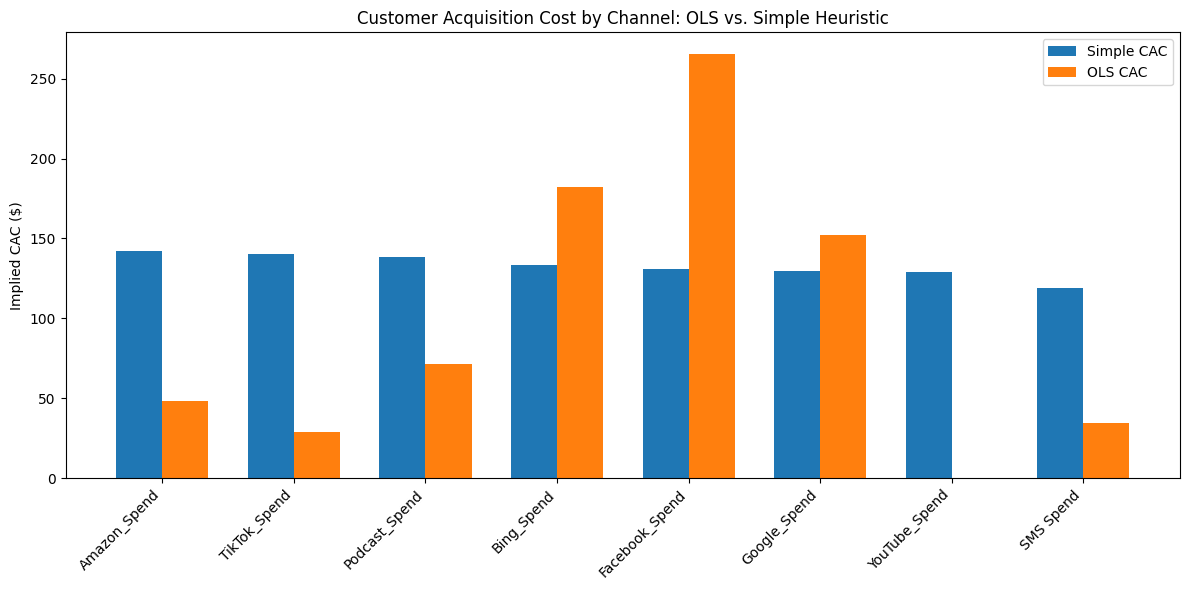

In [38]:
# Merge 
cac_df = pd.merge(
    cac_df_simple[['Channel', 'Total_Spend', 'Implied_CAC_$']],
    cac_df_ols[['Channel', 'Implied_CAC_$']],
    on='Channel',
    suffixes=('_Simple', '_OLS')
)

# Replace inf with NaN for cleaner plotting
cac_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Set up the bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(cac_df))
width = 0.35

# Plot both bars
ax.bar(x - width/2, cac_df['Implied_CAC_$_Simple'], width=width, label='Simple CAC')
ax.bar(x + width/2, cac_df['Implied_CAC_$_OLS'], width=width, label='OLS CAC')

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(cac_df['Channel'], rotation=45, ha='right')
ax.set_ylabel('Implied CAC ($)')
ax.set_title('Customer Acquisition Cost by Channel: OLS vs. Simple Heuristic')
ax.legend()

plt.tight_layout()
plt.show()

In [39]:
cac_df

,Channel,Total_Spend,Implied_CAC_$_Simple,Implied_CAC_$_OLS
0,Amazon_Spend,288851,142.036963,48.091231
1,TikTok_Spend,192861,140.222204,28.688039
2,Podcast_Spend,258492,138.709231,71.385159
3,Bing_Spend,1579000,133.194506,182.317916
4,Facebook_Spend,3750999,130.904022,265.789442
5,Google_Spend,8192569,129.873846,152.362560
6,YouTube_Spend,922781,129.163377,NaN
7,SMS Spend,104994,118.807497,34.646568


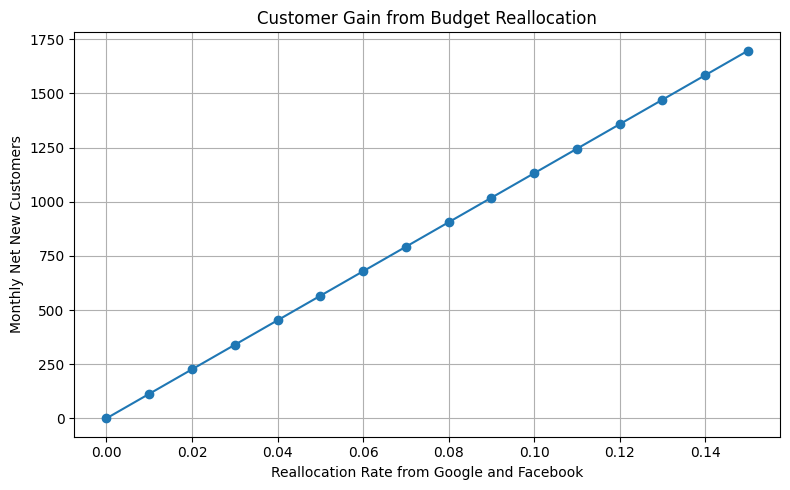

In [40]:
results = []

for reallocation_amount in np.arange(0, 0.151, 0.01): 
    # source and target channels
    sources = ['Facebook_Spend', 'Google_Spend']
    targets = ['SMS Spend', 'TikTok_Spend', 'Podcast_Spend', 'Amazon_Spend']

    # Reallocate X% of source budgets
    reallocation = cac_df[cac_df['Channel'].isin(sources)].copy()
    reallocation['Reallocated'] = reallocation_amount * reallocation['Total_Spend']
    total_shifted_budget = reallocation['Reallocated'].sum()

    # Split reallocated spend equally across target channels
    allocation_per_target = total_shifted_budget / len(targets)

    # Get OLS CACs for source and target channels
    source_cacs = cac_df.set_index('Channel').loc[sources, 'Implied_CAC_$_OLS']
    target_cacs = cac_df.set_index('Channel').loc[targets, 'Implied_CAC_$_OLS']

    # Calculate lost customers from source reduction
    lost_customers = (reallocation.set_index('Channel')['Reallocated'] / source_cacs).sum()

    # Calculate gained customers from reallocating to target channels
    gained_customers = (allocation_per_target / target_cacs).sum()

    # Calculate net impact
    net_customers = gained_customers - lost_customers
    monthly_new_customers = net_customers/df_model['year_month'].nunique()

    results.append({
        'Reallocation_Rate': round(reallocation_amount, 3),
        'Net_Customers': net_customers,
        'Monthly_New_Customers': monthly_new_customers
    })

# Create DataFrame
impact_df = pd.DataFrame(results)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(impact_df['Reallocation_Rate'], impact_df['Monthly_New_Customers'], marker='o')
plt.xlabel('Reallocation Rate from Google and Facebook')
plt.ylabel('Monthly Net New Customers')
plt.title('Customer Gain from Budget Reallocation')
plt.grid(True)
plt.tight_layout()
plt.show()